<a href="https://colab.research.google.com/github/taruni12982/Human-Activity-Recognition-SVM/blob/main/HAR_SVM_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# STEP 1: Install and import libs
# Installing needed packages (only needed once in Colab)
%pip install --quiet scikit-learn pandas matplotlib seaborn joblib
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
import joblib

plt.style.use("seaborn-v0_8-whitegrid")

print(" Libraries imported successfully")


 Libraries imported successfully


In [ ]:
#step 2: load train.csv and test.csv

print("Loading train.csv and test.csv ...")

train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

print(" Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# Quick peek
print("\n First 5 rows of TRAIN:")
display(train_df.head())

print("\n First 5 rows of TEST:")
display(test_df.head())


Loading train.csv and test.csv ...
 Train Shape: (7352, 563)
Test Shape : (2947, 563)

 First 5 rows of TRAIN:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING



 First 5 rows of TEST:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING



 Summary for TRAIN
--------------------------------------------------
                    count unique  top freq      mean       std       min  \
tBodyAcc-mean()-X  7352.0    NaN  NaN  NaN  0.274488  0.070261      -1.0   
tBodyAcc-mean()-Y  7352.0    NaN  NaN  NaN -0.017695  0.040811      -1.0   
tBodyAcc-mean()-Z  7352.0    NaN  NaN  NaN -0.109141  0.056635      -1.0   
tBodyAcc-std()-X   7352.0    NaN  NaN  NaN -0.605438  0.448734      -1.0   
tBodyAcc-std()-Y   7352.0    NaN  NaN  NaN -0.510938  0.502645 -0.999873   

                        25%       50%       75%       max  
tBodyAcc-mean()-X  0.262975  0.277193  0.288461       1.0  
tBodyAcc-mean()-Y -0.024863 -0.017219 -0.010783       1.0  
tBodyAcc-mean()-Z -0.120993 -0.108676 -0.097794       1.0  
tBodyAcc-std()-X  -0.992754 -0.946196 -0.242813       1.0  
tBodyAcc-std()-Y  -0.978129 -0.851897 -0.034231  0.916238  

Missing values (total): 0

 Summary for TEST
--------------------------------------------------
               

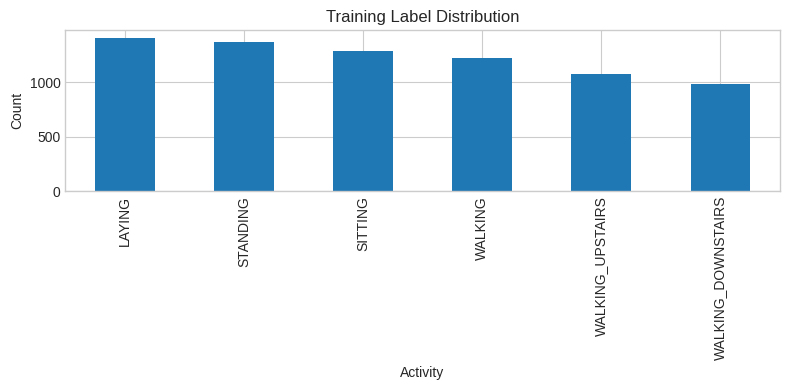

In [ ]:

# STEP 3: Quick data audit & label detection
def summarize_df(df: pd.DataFrame, name: str) -> None:
    print(f"\n Summary for {name}")
    print("-" * 50)
    print(df.describe(include="all").transpose().head())  # first few rows of summary
    print("\nMissing values (total):", df.isna().sum().sum())

summarize_df(train_df, "TRAIN")
summarize_df(test_df, "TEST")
# Try to automatically find label/target column
possible_labels = ["Activity", "activity", "label", "target", "class"]
label_col = next(
    (col for col in possible_labels if col in train_df.columns),
    train_df.columns[-1]  # fallback: last column
)

print(f"\nUsing label column: {label_col}")
# Plot class distribution
plt.figure(figsize=(8, 4))
train_df[label_col].value_counts().plot(kind="bar")
plt.title("Training Label Distribution")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:

# STEP 4: Data cleaning
# - Drop ID/subject columns
# - Remove NaN rows
# - Remove duplicates


def remove_id_columns(df: pd.DataFrame) -> pd.DataFrame:
    # Remove columns like subject, id, experiment id, etc.
    id_cols = [col for col in df.columns
               if "id" in col.lower() or col.lower().startswith("subject")]

    if id_cols:
        print(f"Dropping ID columns: {id_cols}")
        df = df.drop(columns=id_cols)
    return df

print("Cleaning TRAIN...")
train_df = remove_id_columns(train_df)

print(" Cleaning TEST...")
test_df = remove_id_columns(test_df)

# Drop rows with any NaN
print("\nRemoving rows with NaN values...")
before_train = train_df.shape[0]
before_test  = test_df.shape[0]

train_df = train_df.dropna()
test_df  = test_df.dropna()

print(f"TRAIN rows: {before_train} → {train_df.shape[0]} after NaN removal")
print(f"TEST rows : {before_test} → {test_df.shape[0]} after NaN removal")

# Remove duplicates
print("\n Removing duplicate rows...")
before_train = train_df.shape[0]
before_test  = test_df.shape[0]

train_df = train_df.drop_duplicates()
test_df  = test_df.drop_duplicates()

print(f"TRAIN rows: {before_train} → {train_df.shape[0]} after removing duplicates")
print(f"TEST rows : {before_test} → {test_df.shape[0]} after removing duplicates")

print("\n Data cleaning completed.")


Cleaning TRAIN...
Dropping ID columns: ['subject']
 Cleaning TEST...
Dropping ID columns: ['subject']

Removing rows with NaN values...
TRAIN rows: 7352 → 7352 after NaN removal
TEST rows : 2947 → 2947 after NaN removal

 Removing duplicate rows...
TRAIN rows: 7352 → 7352 after removing duplicates
TEST rows : 2947 → 2947 after removing duplicates

 Data cleaning completed.


In [ ]:

# STEP 5: Split into X (features) and y (labels)


# X = all columns except the label column
X_train_full = train_df.drop(columns=[label_col])
y_train_full = train_df[label_col]

# From test_df also separate features and labels
X_test = test_df.drop(columns=[label_col])
y_test = test_df[label_col]

print("Full TRAIN features shape:", X_train_full.shape)
print(" Full TRAIN labels shape  :", y_train_full.shape)
print(" TEST features shape      :", X_test.shape)
print(" TEST labels shape        :", y_test.shape)

# Now split TRAIN into (train + validation)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,          # 20% for validation
    stratify=y_train_full,  # keep class balance
    random_state=42,
)

print("\n After train/validation split:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape  :", X_val.shape)
print("y_val shape  :", y_val.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


Full TRAIN features shape: (7352, 561)
 Full TRAIN labels shape  : (7352,)
 TEST features shape      : (2947, 561)
 TEST labels shape        : (2947,)

 After train/validation split:
X_train shape: (5881, 561)
y_train shape: (5881,)
X_val shape  : (1471, 561)
y_val shape  : (1471,)
X_test shape : (2947, 561)
y_test shape : (2947,)


In [ ]:

# STEP 6: Standardize features


scaler = StandardScaler()

# Fit on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(" Scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape  :", X_val_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)


 Scaling complete.
X_train_scaled shape: (5881, 561)
X_val_scaled shape  : (1471, 561)
X_test_scaled shape : (2947, 561)


In [ ]:

# STEP 7: PCA (retain 95% variance)

pca = PCA(n_components=0.90, svd_solver="full", random_state=42)

# Fit PCA on the TRAIN (scaled) data
X_train_pca = pca.fit_transform(X_train_scaled)

# Apply same PCA transform to validation and test
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original feature count : {X_train.shape[1]}")
print(f"PCA component count   : {pca.n_components_}")

explained = np.sum(pca.explained_variance_ratio_) * 100
print(f"Total variance retained: {explained:.2f}%")


Original feature count : 561
PCA component count   : 63
Total variance retained: 90.12%


In [ ]:

# STEP 8: SVM + GridSearchCV on PCA features

svm = SVC(probability=True, class_weight="balanced", random_state=42)

param_grid = {
    "C": [0.5, 1, 5, 10],
    "gamma": ["scale", 0.01, 0.001],
    "kernel": ["rbf"],   # RBF kernel works very well for HAR
}
print(" Running GridSearchCV ...")
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,          # 5-fold cross-validation
    n_jobs=-1,     # use all CPU cores
    verbose=1,
)
# Train on PCA-transformed training data
grid.fit(X_train_pca, y_train)
best_model = grid.best_estimator_
print("\n Best hyperparameters:", grid.best_params_)
print("Best CV accuracy   :", round(grid.best_score_ * 100, 2), "%")


 Running GridSearchCV ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Best hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy   : 96.68 %


📈 Validation Accuracy: 97.76 %

Validation Classification Report:

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.95      0.93      0.94       257
          STANDING       0.93      0.95      0.94       275
           WALKING       1.00      1.00      1.00       245
WALKING_DOWNSTAIRS       1.00      0.99      1.00       197
  WALKING_UPSTAIRS       1.00      1.00      1.00       215

          accuracy                           0.98      1471
         macro avg       0.98      0.98      0.98      1471
      weighted avg       0.98      0.98      0.98      1471



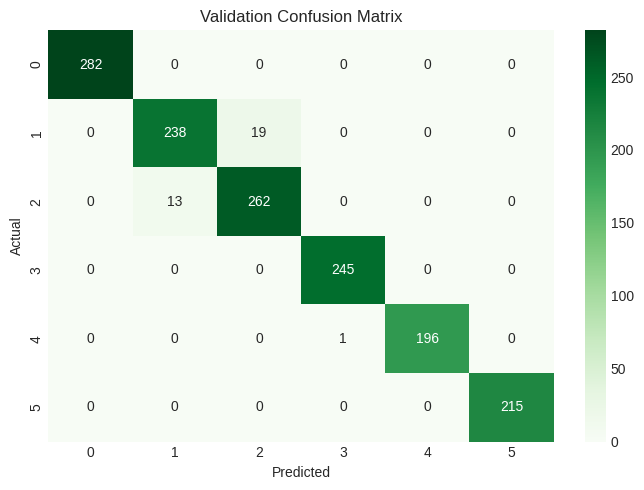

In [ ]:

# STEP 9: Evaluate on validation set


# Predict on validation PCA data
y_val_pred = best_model.predict(X_val_pca)
val_acc = accuracy_score(y_val, y_val_pred)

print("📈 Validation Accuracy:", round(val_acc * 100, 2), "%")
print("\nValidation Classification Report:\n")
print(classification_report(y_val, y_val_pred))

# Confusion matrix
cm_val = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Greens")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()



FINAL TEST ACCURACY: 92.06 %

Test Classification Report:

                    precision    recall  f1-score   support

            LAYING       1.00      0.97      0.98       537
           SITTING       0.89      0.88      0.88       491
          STANDING       0.90      0.93      0.91       532
           WALKING       0.92      0.95      0.93       496
WALKING_DOWNSTAIRS       0.95      0.88      0.91       420
  WALKING_UPSTAIRS       0.88      0.91      0.89       471

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



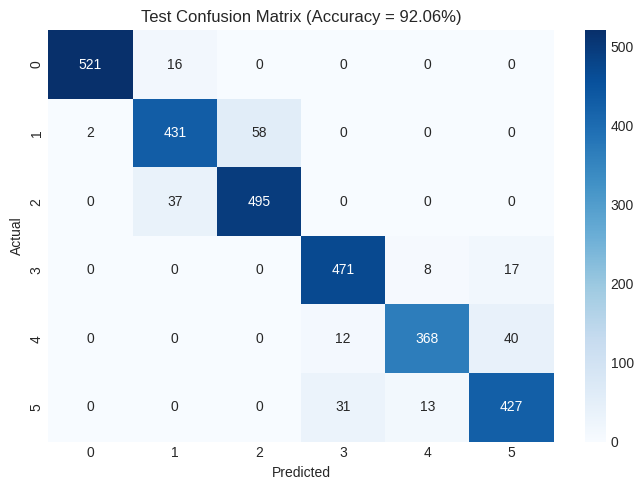

In [ ]:

# STEP 10: Train FINAL model on FULL training data
# and evaluate on TEST data
# 1) Scale FULL training data
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_train_full)

# 2) PCA using SAME number of components from earlier PCA
pca_full = PCA(n_components=pca.n_components_, random_state=42)
X_full_pca = pca_full.fit_transform(X_full_scaled)
# 3) Train SVM using best parameters found before
svm_full = SVC(**grid.best_params_, probability=True, random_state=42)
svm_full.fit(X_full_pca, y_train_full)
# 4) Transform TEST set using full scaler and full PCA
X_test_scaled_full = scaler_full.transform(X_test)
X_test_pca_full = pca_full.transform(X_test_scaled_full)
# 5) Predict on TEST data
y_test_pred = svm_full.predict(X_test_pca_full)
test_acc = accuracy_score(y_test, y_test_pred)

print("\nFINAL TEST ACCURACY:", round(test_acc * 100, 2), "%")
print("\nTest Classification Report:\n")
print(classification_report(y_test, y_test_pred))
# Confusion Matrix (Test)
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues")
plt.title(f"Test Confusion Matrix (Accuracy = {round(test_acc * 100, 2)}%)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:

# STEP 11: Save trained models

from pathlib import Path
import joblib

# Create folder to store models
OUTPUT_DIR = Path("./har_models")
OUTPUT_DIR.mkdir(exist_ok=True)

# Save all components
joblib.dump(scaler_full, OUTPUT_DIR / "scaler.joblib")
joblib.dump(pca_full, OUTPUT_DIR / "pca.joblib")
joblib.dump(svm_full, OUTPUT_DIR / "svm_pca_model.joblib")

print("\n Saved model files inside folder:", OUTPUT_DIR)
print(" - scaler.joblib")
print(" - pca.joblib")
print(" - svm_pca_model.joblib")



 Saved model files inside folder: har_models
 - scaler.joblib
 - pca.joblib
 - svm_pca_model.joblib


In [ ]:
# STEP 12: Activity Prediction Dashboard

def activity_dashboard(index):
    """
    Demonstration function that:
    - Takes a row index from the test dataset
    - Shows actual activity
    - Predicts using trained SVM model
    - Shows confidence + probability distribution
    """

    # Extract sample
    x = test_df.drop(columns=[label_col]).iloc[index].values.reshape(1, -1)
    true_label = test_df[label_col].iloc[index]

    # Apply scaler + PCA
    x_scaled = scaler_full.transform(x)
    x_pca = pca_full.transform(x_scaled)

    # Prediction
    pred = svm_full.predict(x_pca)[0]
    probs = svm_full.predict_proba(x_pca)[0]
    conf = probs.max()

    # Display results
    print("\n📌 Activity Prediction Dashboard")
    print("----------------------------------------")
    print(f"🧪 Test Sample Index     : {index}")
    print(f"🎯 Actual Activity       : {true_label}")
    print(f"🤖 Predicted Activity    : {pred}")
    print(f"🔐 Confidence            : {conf*100:.2f}%")
    print("----------------------------------------")
    print("\n📊 Probability Distribution:")

    for activity, p in zip(svm_full.classes_, probs):
        print(f"   {activity:<20} : {p*100:.2f}%")

    # Visualize probability distribution
    plt.figure(figsize=(7,4))
    sns.barplot(x=svm_full.classes_, y=probs)
    plt.title(f"Activity Prediction Probability (Index {index})")
    plt.ylabel("Probability")
    plt.xticks(rotation=20)     # ← FIXED (wh removed)
    plt.tight_layout()
    plt.show()


print("\n Dashboard Ready!")
print("To test: activity_dashboard(0)")
print(" Try different rows like 5, 10, 100, 500...")



🎉 Dashboard Ready!
👉 To test: activity_dashboard(0)
👉 Try different rows like 5, 10, 100, 500...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



📌 Activity Prediction Dashboard
----------------------------------------
🧪 Test Sample Index     : 2000
🎯 Actual Activity       : WALKING_DOWNSTAIRS
🤖 Predicted Activity    : WALKING_DOWNSTAIRS
🔐 Confidence            : 54.09%
----------------------------------------

📊 Probability Distribution:
   LAYING               : 0.57%
   SITTING              : 1.51%
   STANDING             : 2.25%
   WALKING              : 0.78%
   WALKING_DOWNSTAIRS   : 54.09%
   WALKING_UPSTAIRS     : 40.80%


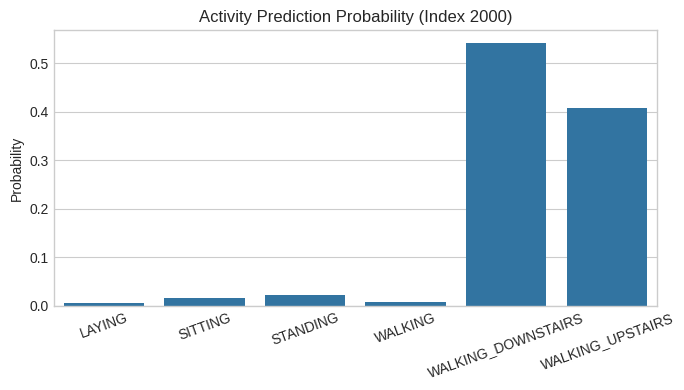

In [ ]:
activity_dashboard(2000)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



📌 Activity Prediction Dashboard
----------------------------------------
🧪 Test Sample Index     : 1534
🎯 Actual Activity       : STANDING
🤖 Predicted Activity    : STANDING
🔐 Confidence            : 97.15%
----------------------------------------

📡 Accelerometer Signals (Sample):
tBodyAcc-mean()-X    0.283088
tBodyAcc-mean()-Y   -0.017006
tBodyAcc-mean()-Z   -0.096796
tBodyAcc-std()-X    -0.974817
tBodyAcc-std()-Y    -0.932839
tBodyAcc-std()-Z    -0.959005
tBodyAcc-mad()-X    -0.979772
tBodyAcc-mad()-Y    -0.928398
tBodyAcc-mad()-Z    -0.957927
tBodyAcc-max()-X    -0.891657
Name: 1534, dtype: object

🌀 Gyroscope Signals (Sample):
tBodyGyro-mean()-X   -0.021619
tBodyGyro-mean()-Y   -0.076555
tBodyGyro-mean()-Z     0.09999
tBodyGyro-std()-X    -0.959299
tBodyGyro-std()-Y    -0.935613
tBodyGyro-std()-Z    -0.970305
tBodyGyro-mad()-X    -0.960528
tBodyGyro-mad()-Y    -0.945282
tBodyGyro-mad()-Z    -0.973488
tBodyGyro-max()-X     -0.84459
Name: 1534, dtype: object

📊 Probability Distribu

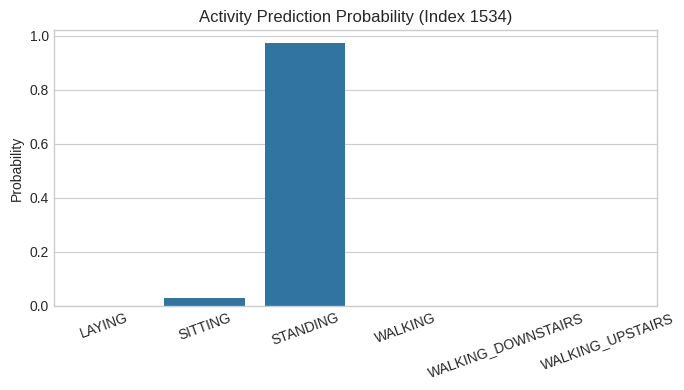

In [ ]:
activity_dashboard(1534)

In [ ]:
# ==============================
# STEP 12: Activity Prediction Dashboard
# ==============================

def activity_dashboard(index):
    """
    Demonstration function that:
    - Takes a row index from the test dataset
    - Shows actual activity
    - Predicts using trained SVM model
    - Shows confidence + probability distribution
    """

    # Extract sample
    x = test_df.drop(columns=[label_col]).iloc[index].values.reshape(1, -1)
    true_label = test_df[label_col].iloc[index]

    # Apply scaler + PCA
    x_scaled = scaler_full.transform(x)
    x_pca = pca_full.transform(x_scaled)

    # Prediction
    pred = svm_full.predict(x_pca)[0]
    probs = svm_full.predict_proba(x_pca)[0]
    conf = probs.max()

    # Display results
    print("\n Activity Prediction Dashboard")
    print("----------------------------------------")
    print(f" Test Sample Index     : {index}")
    print(f" Actual Activity       : {true_label}")
    print(f" Predicted Activity    : {pred}")
    print(f" Confidence            : {conf*100:.2f}%")
    print("----------------------------------------")
    print("\nProbability Distribution:")

    for activity, p in zip(svm_full.classes_, probs):
        print(f"   {activity:<20} : {p*100:.2f}%")

    # Visualize probability distribution
    plt.figure(figsize=(7,4))
    sns.barplot(x=svm_full.classes_, y=probs)
    plt.title(f"Activity Prediction Probability (Index {index})")
    plt.ylabel("Probability")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


print("\n Dashboard Ready!")
print(" To test: activity_dashboard(0)")
print(" Try different rows like 5, 10, 100, 500...")



 Dashboard Ready!
 To test: activity_dashboard(0)
 Try different rows like 5, 10, 100, 500...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



 Activity Prediction Dashboard
----------------------------------------
 Test Sample Index     : 2000
 Actual Activity       : WALKING_DOWNSTAIRS
 Predicted Activity    : WALKING_DOWNSTAIRS
 Confidence            : 54.09%
----------------------------------------

Probability Distribution:
   LAYING               : 0.57%
   SITTING              : 1.51%
   STANDING             : 2.25%
   WALKING              : 0.78%
   WALKING_DOWNSTAIRS   : 54.09%
   WALKING_UPSTAIRS     : 40.80%


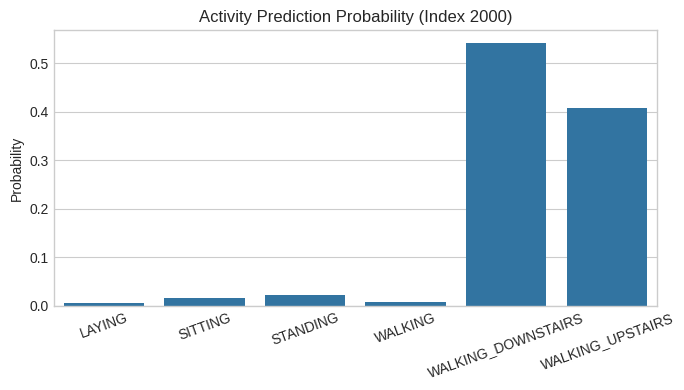

In [ ]:
activity_dashboard(2000)


📌 Activity Prediction Dashboard
----------------------------------------
🧪 Test Sample Index     : 1230
🎯 Actual Activity       : SITTING
🤖 Predicted Activity    : SITTING
🔐 Confidence            : 98.68%
----------------------------------------

📊 Probability Distribution:
   LAYING               : 0.01%
   SITTING              : 98.68%
   STANDING             : 1.29%
   WALKING              : 0.01%
   WALKING_DOWNSTAIRS   : 0.00%
   WALKING_UPSTAIRS     : 0.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


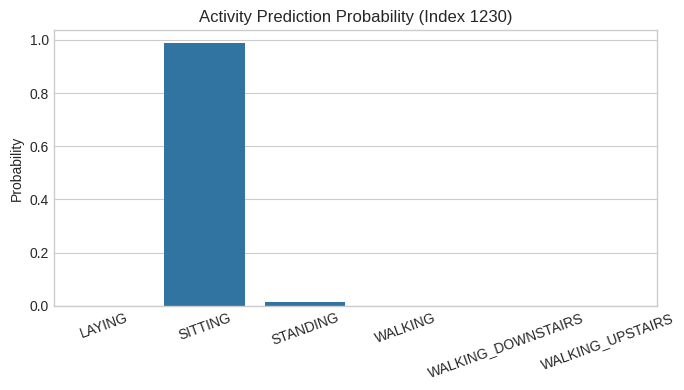

In [ ]:
activity_dashboard(1230)